In [1]:
!pip install ucimlrepo lightgbm shap

In [2]:
import numpy as np
import pandas as pd
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.calibration import CalibratedClassifierCV
from lightgbm import LGBMClassifier

In [3]:
def calc_egfr(creatinine, age, sex):
    """Calculate eGFR using CKD-EPI 2021 formula"""
    k = np.where(sex == 1, 0.7, 0.9)
    alpha = np.where(sex == 1, -0.241, -0.302)
    sex_factor = np.where(sex == 1, 1.012, 1.0)

    scr_k = creatinine / k
    egfr = (
        142 * np.minimum(scr_k, 1)**alpha *
        np.maximum(scr_k, 1)**(-1.200) *
        (0.9938**age) *
        sex_factor
    )
    return egfr

In [4]:
def assign_stage(egfr):
    """Assign CKD stage based on eGFR"""
    if egfr >= 90:
        return "G1"
    elif egfr >= 60:
        return "G2"
    elif egfr >= 45:
        return "G3a"
    elif egfr >= 30:
        return "G3b"
    elif egfr >= 15:
        return "G4"
    else:
        return "G5"

In [5]:
def generate_synthetic(n=120000):
    """Generate synthetic patient data with realistic CKD progression"""
    print(f"GENERATING SYNTHETIC DATA")

    age = np.random.randint(25, 85, n)
    sex = np.random.randint(0, 2, n)

    # Serum Creatinine - primary driver
    n_severe = int(n * 0.03)  # 3% severe CKD (G4-G5)
    n_normal = n - n_severe

    sc_normal = np.random.normal(1.0, 0.5, n_normal)  # Regular patients
    sc_severe = np.random.normal(5.5, 0.8, n_severe)   # Severe patients (SC 4-7)

    sc = np.concatenate([sc_normal, sc_severe])
    np.random.shuffle(sc)  # Mix them randomly
    sc = np.round(sc, 3)
    sc = np.clip(sc, 0.4, 7.0)

    # Calculate eGFR and stage
    egfr = calc_egfr(sc, age, sex)
    stage = np.array([assign_stage(x) for x in egfr])

    # Blood Urea - inversely correlated with eGFR
    bu = np.round(np.random.normal(25 + (7 - (egfr/15)), 10, n), 2)
    bu = np.clip(bu, 5, 180)

    # Hemoglobin - decreases as CKD worsens (anemia)
    hemo = np.round(np.random.normal(14 - (7 - (egfr/20)), 1, n), 2)
    hemo = np.clip(hemo, 6, 17)

    # Packed Cell Volume - roughly 3x hemoglobin
    pcv = hemo * 3 + np.random.uniform(-2, 2, n)

    # Albumin - decreases in CKD (proteinuria/malnutrition)
    al = np.round(4.5 - (90 - egfr) / 30, 2)
    al = np.clip(al, 2.0, 5.4)

    # Specific Gravity - decreases as kidneys lose concentrating ability
    sg = 1.020 - (7 - egfr/20) * 0.0015
    sg = np.clip(sg, 1.002, 1.030)

    df = pd.DataFrame({
        "age": age,
        "sex": sex,
        "sg": sg,
        "al": al,
        "sc": sc,
        "bu": bu,
        "hemo": hemo,
        "pcv": pcv,
        "egfr": egfr,
        "stage": stage
    })

    # Print distribution summary
    print(f"\nGenerated {n:,} synthetic patients")
    print(f"\nStage distribution:")
    stage_counts = df['stage'].value_counts().sort_index()
    for stage, count in stage_counts.items():
        pct = (count/n)*100
        print(f"  {stage}: {count:,} ({pct:.1f}%)")

    print(f"\nFeature summary:")
    print(df[["age","sex","sg","al","sc","bu","hemo","pcv","egfr"]].describe().round(2))

    return df

In [6]:
def train_model(df):
    """Train CKD stage classifier with proper feature name handling"""
    print(f"TRAINING MODEL")

    # Features and target
    feature_cols = ["age","sex","sg","al","sc","bu","hemo","pcv"]
    X = df[feature_cols].copy()
    y = df["stage"]

    print(f"\nFeatures: {feature_cols}")
    print(f"Target: {y.name} with {y.nunique()} classes")
    print(f"Training samples: {len(X):,}")
    print(f"X type: {type(X)}")

    # Encode stages to integers
    enc = OrdinalEncoder()
    y_enc = enc.fit_transform(y.values.reshape(-1,1)).ravel()

    stage_mapping = {i: stage for i, stage in enumerate(enc.categories_[0])}
    print(f"\nStage encoding:")
    for code, stage in stage_mapping.items():
        print(f"  {stage} → {code}")

    # Handle missing values - USE SIMPLEIMPUTER TO PRESERVE DATAFRAME
    print(f"IMPUTING MISSING VALUES")

    # Use SimpleImputer with median strategy (works with DataFrames)
    imputer = SimpleImputer(strategy='median')

    # Fit and transform - but keep checking types
    print(f"Before imputation - X type: {type(X)}, shape: {X.shape}")

    X_imp_array = imputer.fit_transform(X)
    X_imp = pd.DataFrame(X_imp_array, columns=feature_cols, index=X.index)

    print(f"After imputation - X_imp type: {type(X_imp)}, shape: {X_imp.shape}")
    print(f"X_imp columns: {list(X_imp.columns)}")

    missing_before = X.isnull().sum().sum()
    missing_after = X_imp.isnull().sum().sum()
    print(f"Missing values before: {missing_before}")
    print(f"Missing values after: {missing_after}")

    # Train base model with DataFrame
    print(f"TRAINING LIGHTGBM WITH DATAFRAME")

    tree_model = LGBMClassifier(
        n_estimators=500,
        max_depth=-1,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )

    print(f"Training data type going into model: {type(X_imp)}")
    print(f"Training data columns: {list(X_imp.columns)}")

    # Fit with DataFrame to preserve column names
    tree_model.fit(X_imp, y_enc)

    print(f"\nBase model trained successfully")
    print(f"Model type: {type(tree_model)}")
    print(f"n_features_in_: {tree_model.n_features_in_}")
    print(f"n_classes_: {tree_model.n_classes_}")

    # CRITICAL CHECK: Verify feature names were preserved
    if hasattr(tree_model, 'feature_name_'):
        model_feat_names = tree_model.feature_name_
        print(f"feature_name_: {model_feat_names}")

        # Verify they match
        matches = [f1 == f2 for f1, f2 in zip(feature_cols, model_feat_names)]
        if all(matches):
            print(f"ALL FEATURE NAMES PRESERVED CORRECTLY!")
        else:
            print(f"FEATURE NAME MISMATCH DETECTED!")
            for i, (expected, actual, match) in enumerate(zip(feature_cols, model_feat_names, matches)):
                status = "O" if match else "X"
                print(f"  [{i}] {expected} vs {actual} {status}")
    else:
        print(f"ERROR: Model has no feature_name_ attribute!")
        print(f"This means feature names were lost during training")

    # Calibrate probabilities with DataFrame
    print(f"CALIBRATING PROBABILITIES")

    calibrated = CalibratedClassifierCV(tree_model, method="isotonic", cv=3)

    print(f"Calibration data type: {type(X_imp)}")
    calibrated.fit(X_imp, y_enc)

    print(f"Calibration complete")
    print(f"Number of calibrated classifiers: {len(calibrated.calibrated_classifiers_)}")

    # Return numpy array for SHAP background (but model has feature names)
    return calibrated, enc, imputer, tree_model, X_imp.values, feature_cols

In [7]:
def extract_and_verify_tree_model(calibrated, feature_cols):
    """Extract LGBMClassifier with full verification"""
    print(f"EXTRACTING RAW TREE MODEL FOR SHAP")

    # Extract from first fold
    base = calibrated.calibrated_classifiers_[0].estimator

    print(f"Extracted model type: {type(base)}")
    print(f"n_features_in_: {base.n_features_in_}")

    # CRITICAL: Check feature names
    print(f"FEATURE NAME VERIFICATION")

    if hasattr(base, 'feature_name_'):
        model_features = base.feature_name_
        print(f"Model has feature_name_ attribute")
        print(f"Model feature_name_: {model_features}")
        print(f"\nExpected: {feature_cols}")
        print(f"Actual:   {list(model_features)}")

        all_match = all(f1 == f2 for f1, f2 in zip(feature_cols, model_features))

        if all_match:
            print(f"\nPERFECT MATCH - All feature names correct!")
        else:
            print(f"\nMISMATCH - Feature names don't match!")
            for i, (exp, act) in enumerate(zip(feature_cols, model_features)):
                match_str = "O" if exp == act else "X"
                print(f"  [{i}] {exp:20s} vs {act:20s} {match_str}")
    else:
        print(f"CRITICAL ERROR: Model has NO feature_name_ attribute!")
        print(f"Feature names were LOST during training")
        raise ValueError("Model does not have feature names - cannot proceed with SHAP")

    return base

In [8]:
def create_shap_explainer(raw_tree_model, X_imp, feature_cols, n_background=2000):
    """Create SHAP explainer with verification"""
    print(f"CREATING SHAP EXPLAINER")

    # Sample background
    n_samples = min(n_background, X_imp.shape[0])
    background_indices = np.random.choice(X_imp.shape[0], n_samples, replace=False)
    background = X_imp[background_indices]

    print(f"\nBackground shape: {background.shape}")
    print(f"Model expects {raw_tree_model.n_features_in_} features")

    # Create explainer
    print(f"\nCreating TreeExplainer...")
    explainer = shap.TreeExplainer(raw_tree_model, data=background)

    print(f"Explainer created")

    # TEST SHAP
    print(f"TESTING SHAP OUTPUT")

    test_shap = explainer.shap_values(background[:5])

    if isinstance(test_shap, (list, tuple)):
        print(f"SHAP output is list with {len(test_shap)} classes")
        n_features_shap = test_shap[0].shape[1]
        print(f"SHAP returns {n_features_shap} features per sample")

        if n_features_shap == len(feature_cols):
            print(f"SHAP FEATURE COUNT MATCHES: {n_features_shap} = {len(feature_cols)}")
        else:
            print(f"SHAP FEATURE COUNT MISMATCH!")
            print(f"   Expected: {len(feature_cols)}")
            print(f"   Got: {n_features_shap}")
            print(f"   SHAP is only using first {n_features_shap} features!")

            # This is the bug - SHAP is only seeing some features
            print(f"\n   Possible causes:")
            print(f"   1. Model was trained with numpy array (lost names)")
            print(f"   2. Model's feature_name_ has wrong values")
            print(f"   3. LightGBM internal issue")

    return explainer, background

In [9]:
def verify_full_pipeline(model, imputer, explainer, feature_cols):
    """End-to-end verification"""
    print(f"PIPELINE VERIFICATION")

    test_patient = pd.DataFrame({
        "age": [55],
        "sex": [0],
        "sg": [1.015],
        "al": [3.8],
        "sc": [2.5],
        "bu": [65],
        "hemo": [10.2],
        "pcv": [31]
    })

    print(f"\nTest patient:")
    print(test_patient.to_string(index=False))

    # Impute and convert back to DataFrame
    X_test_array = imputer.transform(test_patient[feature_cols])
    X_test = pd.DataFrame(X_test_array, columns=feature_cols)

    print(f"\nAfter imputation type: {type(X_test)}")
    print(f"Columns: {list(X_test.columns)}")

    # Predict
    probs = model.predict_proba(X_test)
    pred_class = probs.argmax()

    print(f"\nPredicted class: {pred_class}")
    print(f"Probabilities: {probs[0]}")

    # SHAP
    shap_vals = explainer.shap_values(X_test.values)

    print(f"\nSHAP computed:")
    if isinstance(shap_vals, (list, tuple)):
        print(f"  Classes: {len(shap_vals)}")
        print(f"  Features per class: {shap_vals[0].shape[1]}")

        # Show SHAP for predicted class
        print(f"\nSHAP breakdown for class {pred_class}:")
        shap_for_pred = shap_vals[pred_class][0]
        for feat, val in zip(feature_cols, shap_for_pred):
            print(f"  {feat:20s}: {val:+8.4f}")

    print(f"VERIFICATION COMPLETE")

In [10]:
if __name__ == "__main__":
    print(f"# CKD STAGE PREDICTION MODEL TRAINING")

    # Generate data
    df_syn = generate_synthetic(120000)

    # Train model
    calibrated, enc, imputer, raw_tree_model, X_imp, feature_cols = train_model(df_syn)

    # Extract and verify
    verified_tree_model = extract_and_verify_tree_model(calibrated, feature_cols)

    # Create SHAP
    explainer, background = create_shap_explainer(verified_tree_model, X_imp, feature_cols)

    # Verify pipeline
    verify_full_pipeline(calibrated, imputer, explainer, feature_cols)

    # Save
    print(f"SAVING MODEL")

    bundle = {
        "model": calibrated,
        "encoder": enc,
        "imputer": imputer,
        "shap_explainer": explainer,
        "raw_tree_model": verified_tree_model,
        "shap_background": background,
        "feature_cols": feature_cols
    }

    joblib.dump(bundle, "ckd_stage_model_final.pkl")

    print(f"\nSaved to: ckd_stage_model_final.pkl")

    # Feature importance
    print(f"FEATURE IMPORTANCE")

    if hasattr(verified_tree_model, 'feature_importances_'):
        importances = verified_tree_model.feature_importances_
        importance_df = pd.DataFrame({
            'feature': feature_cols,
            'importance': importances
        }).sort_values('importance', ascending=False)

        print(f"\n{importance_df.to_string(index=False)}")

        total = importances.sum()
        print(f"\nRelative importance:")
        for feat, imp in zip(importance_df['feature'], importance_df['importance']):
            pct = (imp/total)*100
            bar = '||' * int(pct / 2)
            print(f"  {feat:20s}: {pct:5.1f}% {bar}")

    print(f"# TRAINING COMPLETE")

# CKD STAGE PREDICTION MODEL TRAINING
GENERATING SYNTHETIC DATA

Generated 120,000 synthetic patients

Stage distribution:
  G1: 47,083 (39.2%)
  G2: 31,308 (26.1%)
  G3a: 20,694 (17.2%)
  G3b: 14,959 (12.5%)
  G4: 2,568 (2.1%)
  G5: 3,388 (2.8%)

Feature summary:
             age       sex         sg         al         sc         bu  \
count  120000.00  120000.0  120000.00  120000.00  120000.00  120000.00   
mean       54.51       0.5       1.02       4.06       1.17      26.84   
std        17.27       0.5       0.00       1.00       0.89      10.07   
min        25.00       0.0       1.01       2.00       0.40       5.00   
25%        40.00       0.0       1.01       3.22       0.68      19.89   
50%        55.00       0.0       1.02       4.03       1.02      26.76   
75%        69.00       1.0       1.02       5.02       1.38      33.66   
max        84.00       1.0       1.02       5.40       7.00      69.83   

            hemo        pcv       egfr  
count  120000.00  120000.00

In [22]:
import numpy as np
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
def calc_egfr(creatinine, age, sex):
    """Calculate eGFR using CKD-EPI formula"""
    if pd.isna(creatinine):
        return np.nan

    k = 0.7 if sex == 1 else 0.9
    alpha = -0.241 if sex == 1 else -0.302
    sex_factor = 1.012 if sex == 1 else 1.000

    scr_k = creatinine / k
    egfr = (
        142 * min(scr_k, 1)**alpha *
        max(scr_k, 1)**(-1.200) *
        (0.9938**age) *
        sex_factor
    )
    return egfr

In [24]:
bundle = joblib.load("ckd_stage_model_final.pkl")

model = bundle["model"]
enc = bundle["encoder"]
imputer = bundle["imputer"]
explainer = bundle["shap_explainer"]
raw_tree_model = bundle["raw_tree_model"]
background = bundle["shap_background"]

In [25]:
ALL_FEATURES = ["age","sex","sg","al","sc","bu","hemo","pcv"]
FEAT_PRETTY = {
    "age":"Age",
    "sex":"Sex",
    "sg":"Specific Gravity",
    "al":"Albumin",
    "sc":"Serum Creatinine",
    "bu":"Blood Urea",
    "hemo":"Hemoglobin",
    "pcv":"Packed Cell Volume",
}

In [26]:
def get_shap_class_index(pred_stage):
    """Find correct SHAP output index for a given CKD stage."""
    raw_classes = raw_tree_model.classes_
    stage_labels = enc.inverse_transform(raw_classes.reshape(-1,1)).ravel()

    matches = np.where(stage_labels == pred_stage)[0]
    if len(matches) > 0:
        return matches[0]

    # fallback
    order = {"G1":0,"G2":1,"G3a":2,"G3b":3,"G4":4,"G5":5}
    pred = order.get(pred_stage, 0)
    distances = [abs(pred - order.get(lbl, pred)) for lbl in stage_labels]
    return np.argmin(distances)

In [27]:
def predict_patient(df_patient):
    """Predict CKD stages with confidence scores"""
    X = df_patient[ALL_FEATURES]
    X_imp = imputer.transform(X)

    probs = model.predict_proba(X_imp)
    best_idx = probs.argmax(axis=1)
    stages = enc.inverse_transform(best_idx.reshape(-1,1)).ravel()

    df_patient = df_patient.copy()
    df_patient["pred_stage"] = stages
    df_patient["confidence"] = probs.max(axis=1)

    df_patient["egfr"] = [
        calc_egfr(row.sc, row.age, row.sex)
        for _, row in df_patient.iterrows()
    ]

    return df_patient, X_imp, probs

In [28]:
def print_shap_summary(shap_vals, X_imp, df, t, shap_features):
    """Print feature importance explanation for a single timestamp"""
    # Skip if no data
    if t >= X_imp.shape[0]:
        return

    pred_stage = df.iloc[t]["pred_stage"]
    shap_idx = get_shap_class_index(pred_stage)

    if t >= shap_vals[shap_idx].shape[0]:
        return  # Just skip, don't print

    row = shap_vals[shap_idx][t]

    print(f"\nSHAP Explanation — Timestamp {t} (Predicted {pred_stage}) ")
    for f, v in sorted(zip(shap_features, row), key=lambda x: abs(x[1]), reverse=True):
        if abs(v) < 0.001:
            continue
        direction = "↑ pushes stage HIGHER" if v > 0 else "↓ pushes stage LOWER"
        print(f"  {FEAT_PRETTY[f]}: {v:+.3f}  →  {direction}")

In [29]:
def explain_stage_change(shap_vals, X_imp, df, shap_features):
    """Explain what caused stage transitions between consecutive timestamps"""
    print("\nWHY DID STAGE CHANGE T → T+1 ")

    max_t = min(len(df)-1, X_imp.shape[0]-1)

    for t in range(max_t):
        s_now = df.iloc[t]["pred_stage"]
        s_next = df.iloc[t+1]["pred_stage"]

        idx_now = get_shap_class_index(s_now)
        idx_next = get_shap_class_index(s_next)

        # Silently skip if no data
        if t >= shap_vals[idx_now].shape[0] or (t+1) >= shap_vals[idx_next].shape[0]:
            continue

        shap_now = shap_vals[idx_now][t]
        shap_next = shap_vals[idx_next][t+1]
        diff = shap_next - shap_now

        print(f"\nT{t} ({s_now}) → T{t+1} ({s_next})")
        for f, v in sorted(zip(shap_features, diff), key=lambda x: abs(x[1]), reverse=True)[:4]:
            if abs(v) < 0.01:
                continue
            direction = '↑ worsened CKD' if v > 0 else '↓ improved CKD'
            print(f"  {FEAT_PRETTY[f]}: {direction} ({v:+.3f})")

In [30]:
def plot_all(df):
    """Create comprehensive visualization of patient trajectory"""
    fig, ax = plt.subplots(3, 1, figsize=(14, 16))

    # 1. eGFR Trend
    ax[0].plot(df["t"], df["egfr"], marker="o", linewidth=2, markersize=8, color='#2E86AB')
    ax[0].set_title("eGFR Trend Over Time", fontsize=14, fontweight='bold')
    ax[0].set_ylabel("eGFR (mL/min/1.73m²)", fontsize=12)
    ax[0].set_xlabel("Timestamp", fontsize=12)
    ax[0].grid(alpha=0.3)

    # Reference lines for CKD stages
    for v, label in [(90, "G1/G2"), (60, "G2/G3a"), (45, "G3a/G3b"), (30, "G3b/G4"), (15, "G4/G5")]:
        ax[0].axhline(v, ls="--", alpha=0.4, color='red')
        ax[0].text(df["t"].max(), v, f' {label}', va='center', fontsize=9, alpha=0.7)

    # 2. CKD Stage Trend
    stage_map = {"G1":1, "G2":2, "G3a":3, "G3b":4, "G4":5, "G5":6}
    numeric_stage = df["pred_stage"].map(stage_map)

    ax[1].plot(df["t"], numeric_stage, marker="o", linewidth=2, color="purple", markersize=8)
    ax[1].set_title("Predicted CKD Stage Over Time", fontsize=14, fontweight='bold')
    ax[1].set_ylabel("CKD Stage", fontsize=12)
    ax[1].set_xlabel("Timestamp", fontsize=12)
    ax[1].set_yticks([1,2,3,4,5,6])
    ax[1].set_yticklabels(["G1","G2","G3a","G3b","G4","G5"])
    ax[1].grid(alpha=0.3)
    ax[1].invert_yaxis()

    # 3. Biomarkers
    colors = ['#E63946', '#F1FAEE', '#A8DADC', '#457B9D', '#1D3557', '#2A9D8F']
    for i, f in enumerate(["sg","al","sc","bu","hemo","pcv"]):
        ax[2].plot(df["t"], df[f], marker="o", linewidth=2, label=FEAT_PRETTY[f],
                   markersize=6, color=colors[i % len(colors)])
    ax[2].legend(loc='best', fontsize=10)
    ax[2].set_title("Biomarkers Over Time", fontsize=14, fontweight='bold')
    ax[2].set_xlabel("Timestamp", fontsize=12)
    ax[2].set_ylabel("Value", fontsize=12)
    ax[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [31]:
def plot_shap_heatmap(shap_vals, X_imp, df, shap_features, min_importance=0.01):
    """Create heatmap showing only important features across valid timestamps"""
    max_t = min(X_imp.shape[0], len(df))
    shap_list = []
    valid_timestamps = []

    # Collect only timestamps with valid SHAP data (silently skip invalid)
    for t in range(max_t):
        pred_stage = df.iloc[t]["pred_stage"]
        idx = get_shap_class_index(pred_stage)

        if t < shap_vals[idx].shape[0]:
            shap_list.append(shap_vals[idx][t])
            valid_timestamps.append(t)

    if len(shap_list) == 0:
        print("No valid SHAP data to plot heatmap")
        return

    df_heat = pd.DataFrame(shap_list, columns=shap_features, index=valid_timestamps)

    # Calculate feature importance and filter
    feature_importance = df_heat.abs().mean().sort_values(ascending=False)
    important_features = feature_importance[feature_importance >= min_importance].index.tolist()

    if len(important_features) == 0:
        important_features = feature_importance.nlargest(min(3, len(shap_features))).index.tolist()

    df_heat_filtered = df_heat[important_features]
    pretty_labels = [FEAT_PRETTY[f] for f in important_features]

    # Create heatmap
    plt.figure(figsize=(max(10, len(valid_timestamps) * 0.8), max(5, len(important_features) * 0.8)))
    sns.heatmap(df_heat_filtered.T, cmap="RdBu_r", center=0,
                cbar_kws={'label': 'SHAP Value\n(+ worse CKD, - better CKD)'},
                xticklabels=valid_timestamps,
                yticklabels=pretty_labels,
                linewidths=0.5, linecolor='lightgray',
                annot=True, fmt='.2f', annot_kws={'size': 10, 'weight': 'bold'})

    plt.title("SHAP Feature Influence Heatmap",
              fontsize=15, fontweight='bold', pad=20)
    plt.xlabel("Timestamp", fontsize=13, fontweight='bold')
    plt.ylabel("Feature", fontsize=13, fontweight='bold')
    plt.tight_layout()

    # Print summary
    print(f"HEATMAP SUMMARY")
    print(f"Timestamps included: {valid_timestamps}")
    print(f"Features shown (avg |SHAP| ≥ {min_importance}):")
    for feat in important_features:
        avg_impact = feature_importance[feat]
        print(f"   • {FEAT_PRETTY[feat]}: {avg_impact:.3f}")

    if len(important_features) < len(shap_features):
        print(f"\nX Features excluded (low contribution < {min_importance}):")
        excluded = [f for f in shap_features if f not in important_features]
        for feat in excluded:
            avg_impact = feature_importance[feat]
            print(f"   • {FEAT_PRETTY[feat]}: {avg_impact:.3f}")

    plt.show()

PREDICTING CKD STAGES...

PREDICTION RESULTS:
 t      egfr pred_stage  confidence
 0 80.771052         G1    0.547994
 1 80.771052         G2    1.000000
 2 55.669517         G2    1.000000
 3       NaN         G2    1.000000
 4 39.417672        G3a    0.350510
 5 33.331400        G3a    0.357706
 6 27.497325        G3b    0.565463
 7 23.296621         G5    0.244983
 8 17.157538         G4    0.727522
 9 13.126924         G4    0.798502
GENERATING VISUALIZATIONS...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


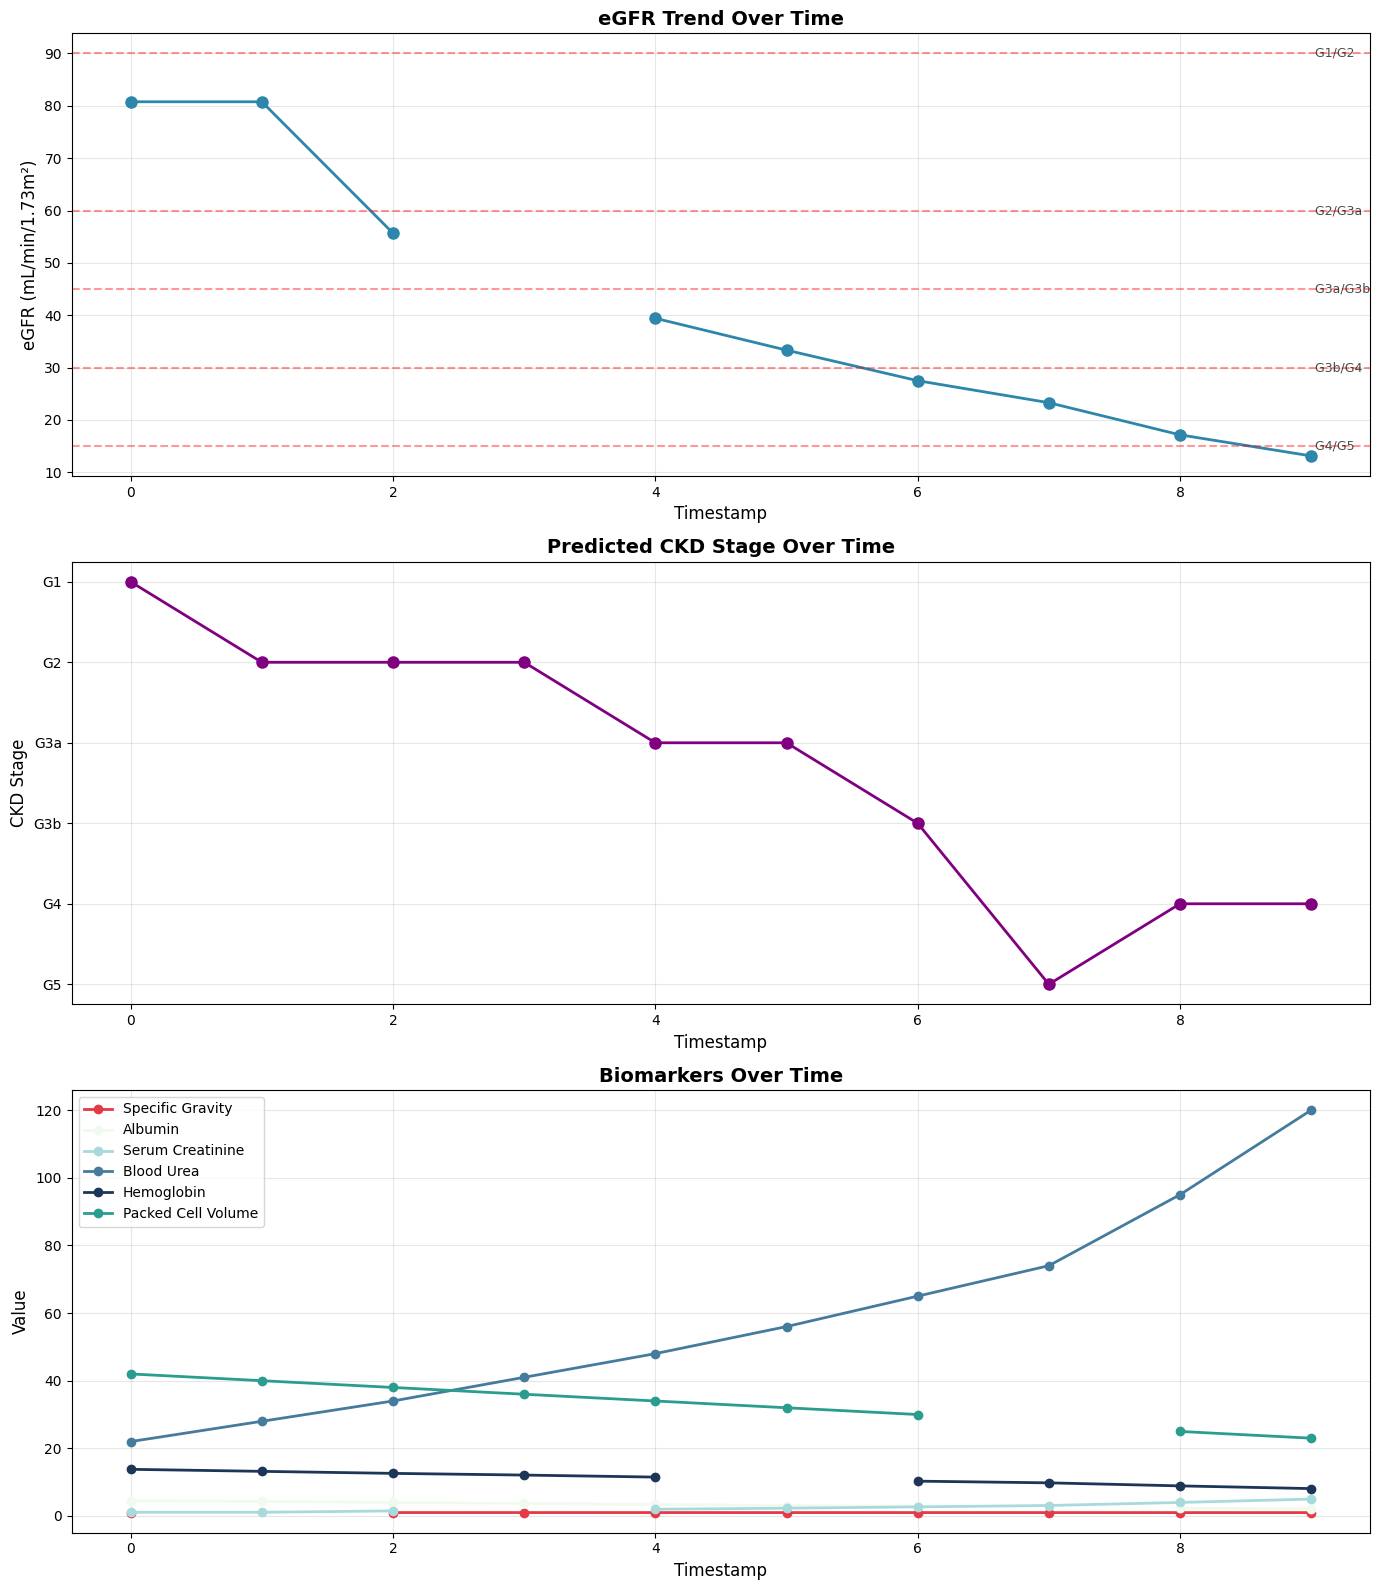

COMPUTING SHAP EXPLANATIONS...
Model trained on: ['age', 'sex', 'sg', 'al', 'sc', 'bu', 'hemo', 'pcv']
SHAP uses 6 features: ['age', 'sex', 'sg', 'al', 'sc', 'bu']
SHAP values shape: [(8, 6), (8, 6), (8, 6), (8, 6), (8, 6), (8, 6), (8, 6), (8, 6), (8, 6), (8, 6)]
Input data shape: (10, 8)
FEATURE IMPORTANCE BY TIMESTAMP

SHAP Explanation — Timestamp 0 (Predicted G1) 
  Sex: +0.319  →  ↑ pushes stage HIGHER
  Age: -0.166  →  ↓ pushes stage LOWER
  Albumin: +0.014  →  ↑ pushes stage HIGHER
  Specific Gravity: +0.013  →  ↑ pushes stage HIGHER
  Serum Creatinine: +0.006  →  ↑ pushes stage HIGHER

SHAP Explanation — Timestamp 1 (Predicted G2) 
  Specific Gravity: -0.100  →  ↓ pushes stage LOWER
  Age: +0.016  →  ↑ pushes stage HIGHER
  Albumin: -0.005  →  ↓ pushes stage LOWER
  Serum Creatinine: -0.002  →  ↓ pushes stage LOWER
  Blood Urea: +0.002  →  ↑ pushes stage HIGHER

SHAP Explanation — Timestamp 2 (Predicted G2) 
  Sex: +5.864  →  ↑ pushes stage HIGHER
  Age: -5.171  →  ↓ pushes stag

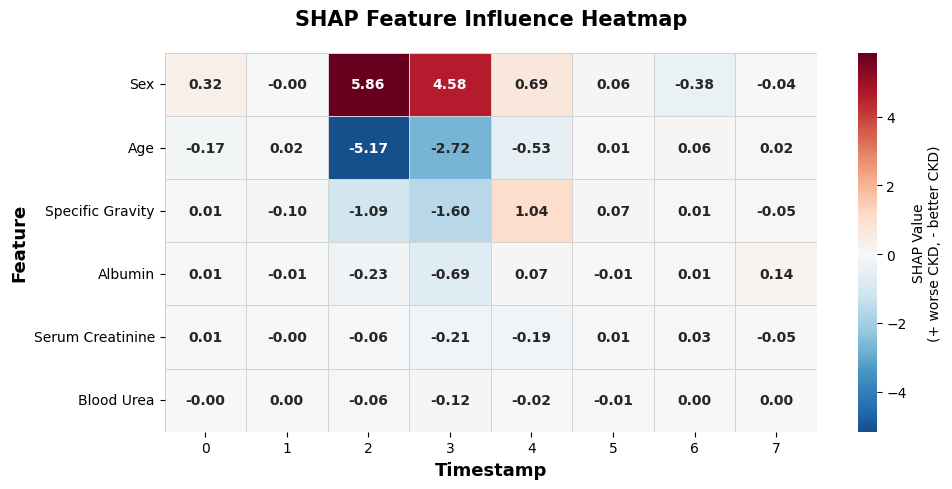

ANALYSIS COMPLETE!


In [32]:
if __name__ == "__main__":
    data = {
        "t": list(range(10)),
        "age": [52]*10,
        "sex": [0]*10,
        "sg":   [1.020, None, 1.016, 1.014, 1.012, 1.010, 1.008, 1.006, 1.004, 1.002],
        "al":   [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.9, None, 2.3, 2.1],
        "sc":   [1.1, 1.1, 1.5, None, 2.0, 2.3, 2.7, 3.1, 4.0, 5.0],
        "bu":   [22, 28, 34, 41, 48, 56, 65, 74, 95, 120],
        "hemo": [13.8, 13.2, 12.6, 12.1, 11.5, None, 10.3, 9.8, 8.9, 8.1],
        "pcv":  [42, 40, 38, 36, 34, 32, 30, None, 25, 23],
    }

    df_patient = pd.DataFrame(data)

    # Predict stages
    print("PREDICTING CKD STAGES...")
    df_pred, X_imp, probs = predict_patient(df_patient)

    print("\nPREDICTION RESULTS:")
    print(df_pred[["t","egfr","pred_stage","confidence"]].to_string(index=False))

    # Visualizations
    print("GENERATING VISUALIZATIONS...")
    plot_all(df_pred)

    # Compute SHAP values
    print("COMPUTING SHAP EXPLANATIONS...")
    shap_vals = explainer.shap_values(X_imp)

    # Detect which features SHAP actually uses
    n_shap_features = shap_vals[0].shape[1]
    shap_features = ALL_FEATURES[:n_shap_features]

    print(f"Model trained on: {ALL_FEATURES}")
    print(f"SHAP uses {n_shap_features} features: {shap_features}")
    print(f"SHAP values shape: {[sv.shape for sv in shap_vals]}")
    print(f"Input data shape: {X_imp.shape}")

    # Per-timestamp SHAP text explanation
    print("FEATURE IMPORTANCE BY TIMESTAMP")
    for t in range(len(df_pred)):
        print_shap_summary(shap_vals, X_imp, df_pred, t, shap_features)

    # Stage change explanations
    explain_stage_change(shap_vals, X_imp, df_pred, shap_features)

    # Heatmap
    print("GENERATING SHAP HEATMAP...")
    plot_shap_heatmap(shap_vals, X_imp, df_pred, shap_features, min_importance=0.01)

    print("ANALYSIS COMPLETE!")